# House 4 — SNN Energy Forecasting

Peak-aware SNN experiment using the REFIT House 4 data.

**Setup**
- 15-minute resampling
- 48 x 15-minute input window (12 hours)
- Inputs: Aggregate + 9 appliance channels + hour sin/cos + aggregate rate-of-change
- Inputs standardized using **training data only**
- Target standardized using a **separate training-only target scaler**
- 2-layer LIF SNN with configurable beta and threshold
- Full temporal membrane trajectory retained for readout
- Learned temporal attention fused with a max-membrane path
- 0.90 quantile loss plus upper-tail weighted MSE
- AdamW
- Early stopping with best validation checkpoint
- Final metrics reported back in Watts


In [31]:
!python -m pip install torch snntorch scikit-learn pandas matplotlib numpy ipykernel

In [32]:
import sys
print(sys.executable)
!pip show torch

/home/ahaandesai/Dev/FYP/.venv/bin/python
Name: torch
Version: 2.14.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: /home/ahaandesai/Dev/FYP/.venv/lib/python3.14/site-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu13, nvidia-cusparselt-cu13, nvidia-nccl-cu13, nvidia-nvshmem-cu13, setuptools, sympy, triton, typing-extensions
Required-by: 


In [33]:
import sys
print(sys.executable)
!where python
!{sys.executable} -m pip show torch

/home/ahaandesai/Dev/FYP/.venv/bin/python
/home/ahaandesai/Dev/FYP/.venv/bin/python
Name: torch
Version: 2.14.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: /home/ahaandesai/Dev/FYP/.venv/lib/python3.14/site-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu13, nvidia-cusparselt-cu13, nvidia-nccl-cu13, nvidia-nvshmem-cu13, setuptools, sympy, triton, typing-extensions
Required-by: 


In [34]:
# ============================================================
# 1. Imports
# ============================================================

!where python
!pip show torch
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


/home/ahaandesai/Dev/FYP/.venv/bin/python
Name: torch
Version: 2.14.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: /home/ahaandesai/Dev/FYP/.venv/lib/python3.14/site-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu13, nvidia-cusparselt-cu13, nvidia-nccl-cu13, nvidia-nvshmem-cu13, setuptools, sympy, triton, typing-extensions
Required-by: 
Device: cuda


In [35]:
# ============================================================
# 2. Configuration
# ============================================================

DATA_PATH = "../data/House_4.csv"

WINDOW = 48          # 48 x 15 min = 12 hours of temporal context
HORIZON = 1          # next 15-minute interval

BATCH_SIZE = 128
EPOCHS = 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

HIDDEN_1 = 32
HIDDEN_2 = 16
BETA = 0.85
THRESHOLD = 0.7

# The upper quantile loss penalizes under-prediction more strongly.
QUANTILE = 0.90
QUANTILE_WEIGHT = 0.60
PEAK_MSE_WEIGHT = 0.40
PEAK_WEIGHT = 3.0

PATIENCE = 7

print("Window:", WINDOW)
print("Horizon:", HORIZON)
print("Learning rate:", LEARNING_RATE)
print("Beta:", BETA)
print("Threshold:", THRESHOLD)
print("Quantile:", QUANTILE)


Window: 48
Horizon: 1
Learning rate: 0.0001
Beta: 0.85
Threshold: 0.7
Quantile: 0.9


In [36]:
# ============================================================
# 3. Load and preprocess House 4
# ============================================================

df = pd.read_csv(DATA_PATH)

df["Time"] = pd.to_datetime(df["Time"])

df = (
    df
    .sort_values("Time")
    .reset_index(drop=True)
)

power_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9"
]

# Keep only required columns
df = df[["Time"] + power_cols].copy()

# 15-minute average
df = (
    df
    .set_index("Time")[power_cols]
    .resample("15min")
    .mean()
    .dropna()
    .reset_index()
)

print("15-minute shape:", df.shape)
print("Time range:", df["Time"].min(), "→", df["Time"].max())


15-minute shape: (53375, 11)
Time range: 2013-10-11 10:15:00 → 2015-07-07 09:45:00


In [37]:
# ============================================================
# 4. Create time features, rate-of-change, and target
# ============================================================

hour = df["Time"].dt.hour + df["Time"].dt.minute / 60.0

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Change from the previous 15-minute aggregate.
# shift(1) means this uses only past information.
df["agg_diff"] = df["Aggregate"].diff()

# First row has no previous value.
df["agg_diff"] = df["agg_diff"].fillna(0)

# Future aggregate target.
df["Target"] = df["Aggregate"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)


Final shape: (53374, 15)


count    53374.000000
mean       379.428953
std        321.179805
min          0.000000
50%        320.727188
75%        470.629297
90%        618.071592
95%        801.759808
99%       1630.318950
max       7814.576271
Name: Target, dtype: float64

Percentiles:
P50: 320.73 W
P75: 470.63 W
P90: 618.07 W
P95: 801.76 W
P99: 1630.32 W
Maximum: 7814.58 W


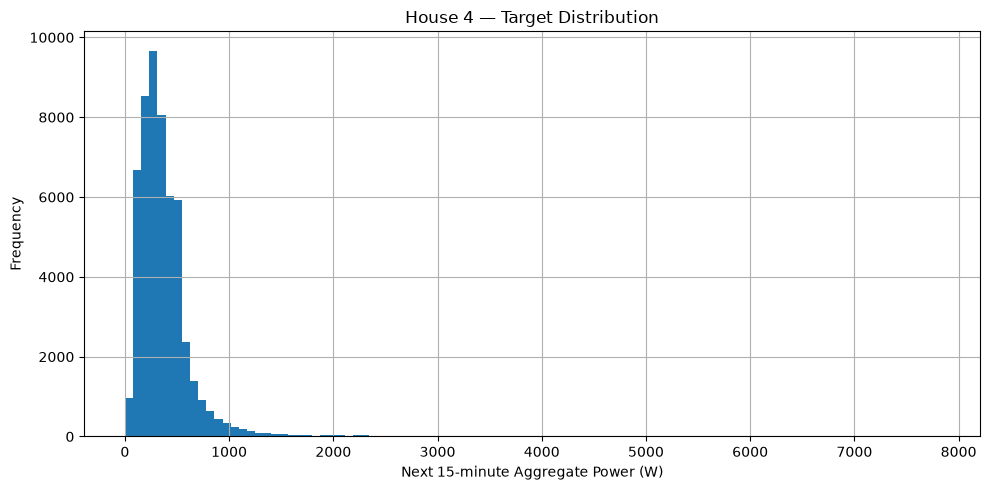

In [38]:
# ============================================================
# 5. Target distribution
# ============================================================

target = df["Target"].values

print(df["Target"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"P{p}: {np.percentile(target, p):.2f} W")

print(f"Maximum: {target.max():.2f} W")

plt.figure(figsize=(10, 5))
plt.hist(target, bins=100)
plt.xlabel("Next 15-minute Aggregate Power (W)")
plt.ylabel("Frequency")
plt.title("House 4 — Target Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
# ============================================================
# 6. Chronological train / validation / test split
# ============================================================

n = len(df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (37361, 15)
Val:   (8006, 15)
Test:  (8007, 15)


In [40]:
# ============================================================
# 7. Feature scaling and peak-range diagnostics
# ============================================================

# Power/appliance input scaler
power_scaler = StandardScaler()

train_power_scaled = power_scaler.fit_transform(
    train_df[power_cols]
)

val_power_scaled = power_scaler.transform(
    val_df[power_cols]
)

test_power_scaled = power_scaler.transform(
    test_df[power_cols]
)


# Aggregate-difference scaler
diff_scaler = StandardScaler()

train_df["agg_diff_scaled"] = diff_scaler.fit_transform(
    train_df[["agg_diff"]]
).ravel()

val_df["agg_diff_scaled"] = diff_scaler.transform(
    val_df[["agg_diff"]]
).ravel()

test_df["agg_diff_scaled"] = diff_scaler.transform(
    test_df[["agg_diff"]]
).ravel()


# Separate target scaler fitted only on training Aggregate values.
target_scaler = StandardScaler()
target_scaler.fit(train_df[["Aggregate"]].to_numpy())

# Use arrays here because the scaler was fitted on Aggregate, not Target.
train_target_scaled = target_scaler.transform(
    train_df[["Target"]].to_numpy()
).ravel()
val_target_scaled = target_scaler.transform(
    val_df[["Target"]].to_numpy()
).ravel()
test_target_scaled = target_scaler.transform(
    test_df[["Target"]].to_numpy()
).ravel()

print("Target mean:", target_scaler.mean_[0])
print("Target std: ", target_scaler.scale_[0])
print("Train Aggregate range:", train_df["Aggregate"].min(), "to", train_df["Aggregate"].max(), "W")
print("Train target scaled range:", train_target_scaled.min(), "to", train_target_scaled.max())
print("Val target scaled range:", val_target_scaled.min(), "to", val_target_scaled.max())
print("Test target scaled range:", test_target_scaled.min(), "to", test_target_scaled.max())
print("StandardScaler clipping:", False, "(standardization does not clip values)")


Target mean: 386.13973728246657
Target std:  332.47918268747156
Train Aggregate range: 0.0 to 7814.576271186441 W
Train target scaled range: -1.1613952313081677 to 22.342561341311583
Val target scaled range: -0.9860888743369328 to 15.248608460601796
Test target scaled range: -1.1613952313081677 to 12.5809342120162
StandardScaler clipping: False (standardization does not clip values)


In [41]:
# ============================================================
# 8. Create temporal sequences
# ============================================================

feature_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9",
    "hour_sin",
    "hour_cos",
    "agg_diff_scaled"
]

def create_sequences(power_scaled, df_split, target_scaled, window=WINDOW):
    X = []
    y = []

    hour_sin = df_split["hour_sin"].values
    hour_cos = df_split["hour_cos"].values
    agg_diff = df_split["agg_diff_scaled"].values

    for i in range(len(power_scaled) - window):
        sequence = np.column_stack([
            power_scaled[i:i + window],
            hour_sin[i:i + window],
            hour_cos[i:i + window],
            agg_diff[i:i + window]
        ])

        X.append(sequence)
        y.append(target_scaled[i + window - 1])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1)
    )


X_train, y_train = create_sequences(
    train_power_scaled, train_df, train_target_scaled, WINDOW
)

X_val, y_val = create_sequences(
    val_power_scaled, val_df, val_target_scaled, WINDOW
)

X_test, y_test = create_sequences(
    test_power_scaled, test_df, test_target_scaled, WINDOW
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)


X_train: (37313, 48, 13)
y_train: (37313, 1)
X_val:   (7958, 48, 13)
y_val:   (7958, 1)
X_test:  (7959, 48, 13)
y_test:  (7959, 1)


In [42]:
# ============================================================
# 9. DataLoaders
# ============================================================

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train),
        torch.tensor(y_train)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val),
        torch.tensor(y_val)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test),
        torch.tensor(y_test)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 292
Validation batches: 63
Test batches: 63


In [43]:
# ============================================================
# 10. SNN — peak-preserving temporal readout
# ============================================================

class SNNForecaster(nn.Module):

    def __init__(
        self,
        input_size=13,
        hidden1=32,
        hidden2=16,
        beta=0.85,
        threshold=0.7
    ):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.lif1 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=surrogate.fast_sigmoid(slope=25)
        )

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.lif2 = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=surrogate.fast_sigmoid(slope=25)
        )

        # Learn which temporal states matter, while retaining the strongest state.
        self.attention = nn.Sequential(
            nn.Linear(hidden2, hidden2),
            nn.Tanh(),
            nn.Linear(hidden2, 1)
        )
        self.output = nn.Linear(hidden2 * 2, 1)

    def forward(self, x):
        # x = [batch, time, features]
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        states = []

        for t in range(x.size(1)):
            cur1 = self.fc1(x[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            _, mem2 = self.lif2(cur2, mem2)
            states.append(mem2)

        states = torch.stack(states, dim=1)
        attention_scores = self.attention(states).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)
        attended_state = torch.sum(states * attention_weights.unsqueeze(-1), dim=1)
        max_state = torch.max(states, dim=1).values

        return self.output(torch.cat([attended_state, max_state], dim=-1))


model = SNNForecaster(
    input_size=X_train.shape[-1],
    hidden1=HIDDEN_1,
    hidden2=HIDDEN_2,
    beta=BETA,
    threshold=THRESHOLD
).to(DEVICE)

print(model)
print(
    "\nTrainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


SNNForecaster(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (lif2): Leaky()
  (attention): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Trainable parameters: 1298


In [44]:
# ============================================================
# 11. Train with peak-aware quantile loss and early stopping
# ============================================================

mse_criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_state = None
best_epoch = 0
patience_counter = 0


def peak_aware_loss(pred, target):
    error = target - pred
    quantile_loss = torch.maximum(
        QUANTILE * error,
        (QUANTILE - 1.0) * error
    ).mean()

    # Upweight examples in the upper tail of the standardized target.
    peak_cutoff = torch.quantile(target.detach(), 0.90)
    peak_weights = torch.where(
        target.detach() >= peak_cutoff,
        torch.full_like(target, PEAK_WEIGHT),
        torch.ones_like(target)
    )
    weighted_mse = (peak_weights * (pred - target).pow(2)).mean()

    return (
        QUANTILE_WEIGHT * quantile_loss
        + PEAK_MSE_WEIGHT * weighted_mse
    )


for epoch in range(EPOCHS):
    model.train()
    train_total = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        pred = model(xb)
        loss = peak_aware_loss(pred, yb)
        loss.backward()
        optimizer.step()

        train_total += loss.item()

    train_loss = train_total / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_total = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb.to(DEVICE))
            val_total += peak_aware_loss(pred, yb.to(DEVICE)).item()

    val_loss = val_total / len(val_loader)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | Val {val_loss:.6f}"
    )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break


model.load_state_dict(best_state)
print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.6f}")


Epoch 01/50 | Train 1.102638 | Val 0.941055
Epoch 02/50 | Train 1.061997 | Val 0.910754
Epoch 03/50 | Train 1.049963 | Val 0.899245
Epoch 04/50 | Train 1.044181 | Val 0.890030
Epoch 05/50 | Train 1.036451 | Val 0.882565
Epoch 06/50 | Train 1.029565 | Val 0.885583
Epoch 07/50 | Train 1.023321 | Val 0.877073
Epoch 08/50 | Train 1.024450 | Val 0.874334
Epoch 09/50 | Train 1.014790 | Val 0.874022
Epoch 10/50 | Train 1.012429 | Val 0.872294
Epoch 11/50 | Train 1.008474 | Val 0.867111
Epoch 12/50 | Train 1.000624 | Val 0.871790
Epoch 13/50 | Train 0.996705 | Val 0.862714
Epoch 14/50 | Train 0.992082 | Val 0.864099
Epoch 15/50 | Train 0.988851 | Val 0.861344
Epoch 16/50 | Train 0.987700 | Val 0.856208
Epoch 17/50 | Train 0.980944 | Val 0.855318
Epoch 18/50 | Train 0.977816 | Val 0.855072
Epoch 19/50 | Train 0.976113 | Val 0.852762
Epoch 20/50 | Train 0.974879 | Val 0.853884
Epoch 21/50 | Train 0.969750 | Val 0.848514
Epoch 22/50 | Train 0.968406 | Val 0.845089
Epoch 23/50 | Train 0.965220 | V

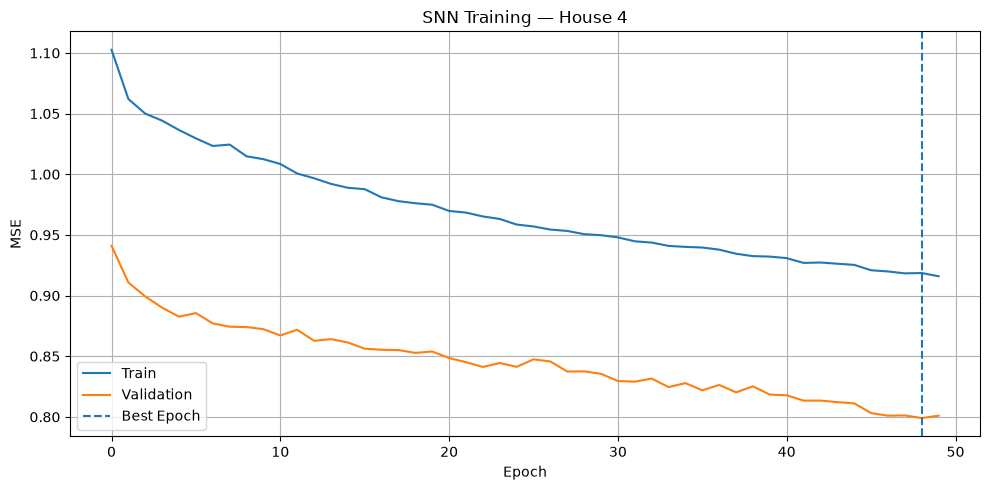

In [45]:
# ============================================================
# 12. Training / validation loss
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label="Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SNN Training — House 4")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [46]:
# ============================================================
# 13. Test predictions
# ============================================================

model.eval()

pred_scaled = []
actual_scaled = []

with torch.no_grad():

    for xb, yb in test_loader:

        pred = model(
            xb.to(DEVICE)
        )

        pred_scaled.append(
            pred.cpu().numpy()
        )

        actual_scaled.append(
            yb.numpy()
        )

pred_scaled = np.concatenate(
    pred_scaled
).reshape(-1, 1)

actual_scaled = np.concatenate(
    actual_scaled
).reshape(-1, 1)


# ------------------------------------------------------------
# Convert back to actual Watts
# ------------------------------------------------------------

pred_watts = target_scaler.inverse_transform(
    pred_scaled
).ravel()

actual_watts = target_scaler.inverse_transform(
    actual_scaled
).ravel()

print("Predictions:", pred_watts.shape)


Predictions: (7959,)


In [47]:
# ============================================================
# 14. Evaluation
# ============================================================

def evaluate_power(actual, pred, name):

    actual = np.asarray(actual).ravel()
    pred = np.asarray(pred).ravel()

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    r2 = r2_score(
        actual,
        pred
    )

    # Top 10% actual loads
    p90 = np.percentile(
        actual,
        90
    )

    mask = actual >= p90

    peak_mae = mean_absolute_error(
        actual[mask],
        pred[mask]
    )

    peak_rmse = np.sqrt(
        mean_squared_error(
            actual[mask],
            pred[mask]
        )
    )

    peak_ratio = (
        pred.max() / actual.max()
    )

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print(f"MAE       : {mae:.2f} W")
    print(f"RMSE      : {rmse:.2f} W")
    print(f"R²        : {r2:.4f}")
    print(f"Peak MAE  : {peak_mae:.2f} W")
    print(f"Peak RMSE : {peak_rmse:.2f} W")
    print(f"Actual max: {actual.max():.2f} W")
    print(f"Pred max  : {pred.max():.2f} W")
    print(f"Peak ratio: {peak_ratio:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Peak_MAE": peak_mae,
        "Peak_RMSE": peak_rmse,
        "Actual_Max": actual.max(),
        "Pred_Max": pred.max(),
        "Peak_Ratio": peak_ratio
    }


result = evaluate_power(
    actual_watts,
    pred_watts,
    "SNN — House 4"
)



SNN — House 4
MAE       : 220.02 W
RMSE      : 301.70 W
R²        : -0.2255
Peak MAE  : 357.48 W
Peak RMSE : 599.89 W
Actual max: 4569.04 W
Pred max  : 1052.85 W
Peak ratio: 0.2304


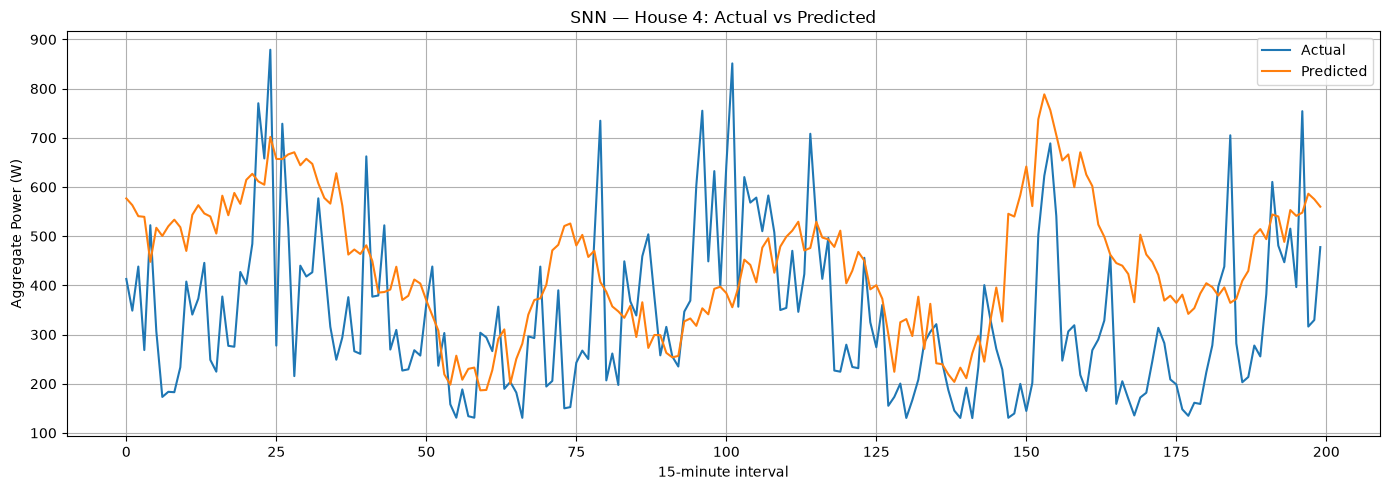

In [48]:
# ============================================================
# 15. Actual vs predicted — first 200 test intervals
# ============================================================

points = min(
    200,
    len(actual_watts)
)

plt.figure(figsize=(14, 5))

plt.plot(
    actual_watts[:points],
    label="Actual"
)

plt.plot(
    pred_watts[:points],
    label="Predicted"
)

plt.xlabel("15-minute interval")
plt.ylabel("Aggregate Power (W)")
plt.title("SNN — House 4: Actual vs Predicted")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
# ============================================================
# 16. Peak diagnostic
# ============================================================

p90 = np.percentile(actual_watts, 90)
peak_mask = actual_watts >= p90

print("P90 threshold:", f"{p90:.2f} W")
print(
    "Actual mean at P90+:",
    f"{actual_watts[peak_mask].mean():.2f} W"
)
print(
    "Predicted mean at P90+:",
    f"{pred_watts[peak_mask].mean():.2f} W"
)
print("Actual maximum:", f"{actual_watts.max():.2f} W")
print("Predicted maximum:", f"{pred_watts.max():.2f} W")
print("Peak ratio:", f"{pred_watts.max() / actual_watts.max():.4f}")

# Compare the target range with the standardized range used for training.
print("\nTarget scaling diagnostic:")
print("Training target z-score maximum:", f"{train_target_scaled.max():.3f}")
print("Test target z-score maximum:", f"{test_target_scaled.max():.3f}")
print("StandardScaler clipping detected: False")


P90 threshold: 571.44 W
Actual mean at P90+: 905.25 W
Predicted mean at P90+: 573.25 W
Actual maximum: 4569.04 W
Predicted maximum: 1052.85 W
Peak ratio: 0.2304

Target scaling diagnostic:
Training target z-score maximum: 22.343
Test target z-score maximum: 12.581
StandardScaler clipping detected: False


## Experiment notes

This version tests the peak failure modes before changing the network depth:

- A 48-step window gives the recurrent state 12 hours of context.
- A lower configurable threshold and steeper surrogate gradient reduce premature saturation.
- Attention can select important timesteps, while max membrane preserves rare high activations.
- The 0.90 quantile term discourages under-predicting high loads.
- Upper-tail weighted MSE keeps large peak errors important without discarding overall accuracy.
- The scaling diagnostics show the standardized peak range; `StandardScaler` does not clip values.

All predictions are converted back to **Watts** before evaluation.
